In [1]:
import polars as pl
from pathlib import Path

ROOT = Path.cwd()
OUT_DIR = ROOT / "data" / "output"
if not OUT_DIR.exists():
    OUT_DIR = ROOT.parent / "data" / "output"

parquet_path = OUT_DIR / "forecast_seccion_1_partial.parquet"
if not parquet_path.exists():
    raise FileNotFoundError(f"Parquet file not found: {parquet_path}")

df = pl.read_parquet(parquet_path)
out = df.filter(pl.col("unique_id") == "1").select(["value", "valuehat"])
out.write_csv("forecast_seccion_1_partial_uid_1.csv")
print("Archivo generado: forecast_seccion_1_partial_uid_1.csv")

Archivo generado: forecast_seccion_1_partial_uid_1.csv


shape: (5, 3)
┌────────────┬───────────┬───────────┐
│ ds         ┆ value     ┆ valuehat  │
│ ---        ┆ ---       ┆ ---       │
│ date       ┆ f64       ┆ f64       │
╞════════════╪═══════════╪═══════════╡
│ 2024-05-26 ┆ 2134653.8 ┆ 2134653.8 │
│ 2024-05-27 ┆ 1.9304e6  ┆ 2.1142e6  │
│ 2024-05-28 ┆ 2.0906e6  ┆ 2.1119e6  │
│ 2024-05-29 ┆ 1.8514e6  ┆ 2.0858e6  │
│ 2024-05-30 ┆ 1.7116e6  ┆ 2.0484e6  │
└────────────┴───────────┴───────────┘


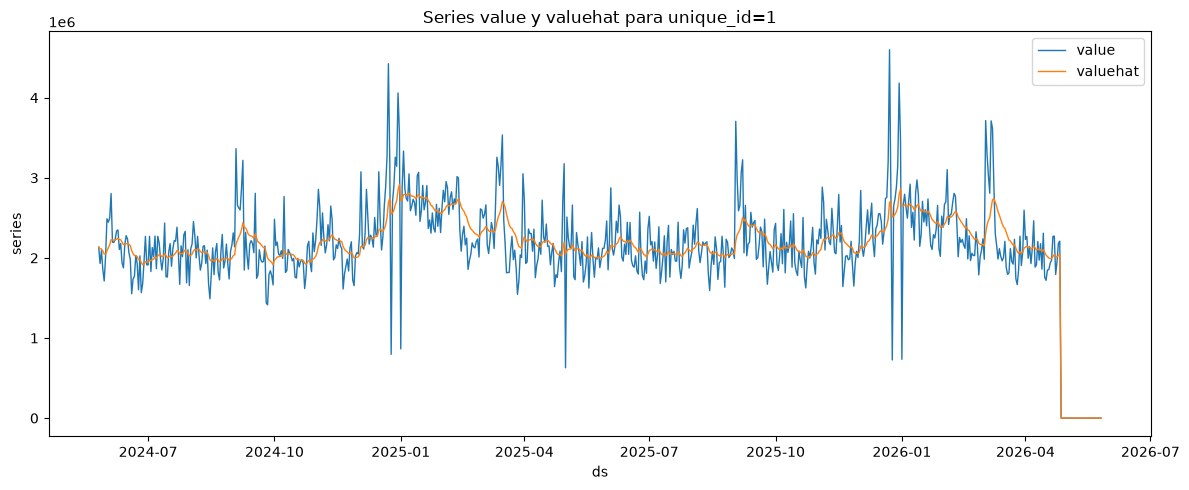

In [2]:
import matplotlib.pyplot as plt


def graph_plot(filtered: pl.DataFrame):
    x = filtered["ds"].to_list()
    y_value = filtered["value"].to_list()
    y_valuehat = filtered["valuehat"].to_list()

    plt.figure(figsize=(12, 5))
    plt.plot(x, y_value, label="value", linewidth=1)
    plt.plot(x, y_valuehat, label="valuehat", linewidth=1)
    plt.xlabel("ds")
    plt.ylabel("series")
    plt.title("Series value y valuehat para unique_id=1")
    plt.legend()
    plt.tight_layout()
    plt.show()


filtered = (
    df.filter(pl.col("unique_id") == "1").select(["ds", "value", "valuehat"]).sort("ds")
)

print(filtered.head())

graph_plot(filtered)

In [3]:
# Mostrar cantidad de filas por cada unique_id
counts = (
    df.group_by("unique_id")
    .agg(pl.len().alias("n_rows"))
    .sort("n_rows", descending=True)
)
print(counts.head(10))

shape: (10, 2)
┌──────────────────┬────────┐
│ unique_id        ┆ n_rows │
│ ---              ┆ ---    │
│ str              ┆ u32    │
╞══════════════════╪════════╡
│ 1||00122||382505 ┆ 731    │
│ 1||00122||408036 ┆ 731    │
│ 1||00003||229605 ┆ 731    │
│ 1||00003||545    ┆ 731    │
│ 1||00003||402936 ┆ 731    │
│ 1||00001||400077 ┆ 731    │
│ 1||00411||172730 ┆ 731    │
│ 1||00001||408730 ┆ 731    │
│ 1||00003||109775 ┆ 731    │
│ 1||00063||471462 ┆ 731    │
└──────────────────┴────────┘


In [4]:
wmape_path = OUT_DIR / "wmape.parquet"

df_wmape = pl.read_parquet(wmape_path)
df_wmape.filter(
    (pl.col("wmape") != 0) & pl.col("unique_id").str.starts_with("1||")
).sort("wmape", descending=False)

unique_id,wmape,sum_y,n_with_sales,n_ds
str,f64,f64,i64,i64
"""1||00025||533849""",1.4803e-16,3.0,1,28
"""1||00001||505107""",2.2204e-16,1.0,1,28
"""1||00001||589008""",2.2204e-16,1.0,1,28
"""1||00025||113755""",2.2204e-16,1.0,1,28
"""1||00025||403612""",2.2204e-16,1.0,1,28
…,…,…,…,…
"""1||00001||412482""",27.29405,1.0,1,28
"""1||00211||594885""",27.632536,0.12,1,28
"""1||00411||205005""",28.756169,4.0,3,28


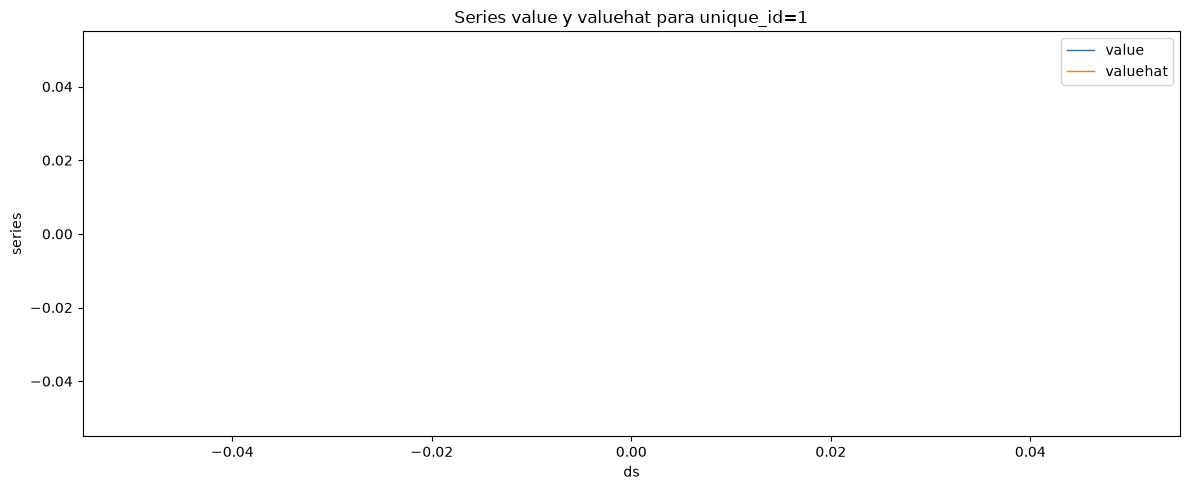

In [5]:
filtered = (
    df.filter(pl.col("unique_id") == "1||T:00063")
    .select(["ds", "value", "valuehat"])
    .sort("ds")
)

graph_plot(filtered)

In [6]:
df.filter(
    (pl.col("unique_id") == "1||T:00063") & (pl.col("period_type") == "forecast_only")
).sort("ds")

unique_id,ds,y,yhat,value,valuehat,train_start,train_end,test_start,test_end,forecast_start,forecast_end,sku_desc,store_name,seccion,conteo_sku,period_type
str,date,f64,f64,f64,f64,date,date,date,date,date,date,str,str,str,i64,str
